# 09g — Integrated Pipeline-5 Lead Selection

## PEARL — EGFR 3NJP

This notebook closes Pipeline 5 by integrating the evidence produced by:

```text
09b — consolidated MD-derived pharmacophore
09c — molecule generation/acquisition + pharmacophore screening
09d — chemistry, drug-likeness, liabilities and diversity
09e — DiffDock pose generation + receptor-contact analysis
09f — Vina scoring of the selected DiffDock pose + local energetic refinement
```

The integration is intentionally **multi-criterion**.

It does **not** invent a universal binding score by adding together quantities with different
physical meanings. Instead it reports:

- pharmacophore fit;
- chemistry / drug-likeness;
- DiffDock structural support;
- receptor engagement;
- Vina energetic support;
- stability of the DiffDock pose under local Vina refinement;
- agreement and disagreement between methods.

A transparent consensus rule is used only for **priority assignment**, not as a surrogate
binding free energy.


## 1. Scientific interpretation rules

The following distinctions are preserved throughout the notebook.

### Pharmacophore
The current small-molecule finalists are rescue compounds derived from the
`NEAR_MISS_MANDATORY_ONLY` track. Favorable docking or Vina refinement does not relabel
them as strict pharmacophore hits.

### DiffDock
DiffDock confidence is a model-derived pose-confidence signal. It is not a binding free
energy.

### Vina
Vina scores are empirical docking-scoring-function outputs. More negative values are more
favorable **only within this common protocol**.

### Local Vina RMSD
A small DiffDock→Vina local RMSD indicates that Vina could improve the energetic score
without requiring a major rearrangement of the DiffDock pose.

### Final priority
Priority is based on **cross-method convergence**. It should be read as a computational
selection for follow-up, not proof of experimental binding.


In [1]:
from pathlib import Path
import json
import math
import shutil
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("09g PEARL integrated lead-selection environment loaded.")


09g PEARL integrated lead-selection environment loaded.


## 2. Configuration


In [2]:
OUTPUTS_ROOT = Path("outputs")

ROOT_09B = (
    OUTPUTS_ROOT
    / "pipeline_5_pharmacophore_09b_consolidated"
)

ROOT_09C = (
    OUTPUTS_ROOT
    / "pipeline_5_pharmacophore_09c_generation"
    / "production"
)

ROOT_09D = (
    OUTPUTS_ROOT
    / "pipeline_5_pharmacophore_09d_chemical_filtering"
)

ROOT_09E = (
    OUTPUTS_ROOT
    / "pipeline_5_pharmacophore_09e_diffdock"
)

ROOT_09F = (
    OUTPUTS_ROOT
    / "pipeline_5_pharmacophore_09f_vina_refinement"
)

OUTPUT_ROOT = (
    OUTPUTS_ROOT
    / "pipeline_5_pharmacophore_09g_integrated_lead_selection"
)

TABLE_DIR = OUTPUT_ROOT / "tables"
PLOT_DIR = OUTPUT_ROOT / "plots"
REPORT_DIR = OUTPUT_ROOT / "reports"
STRUCTURE_DIR = OUTPUT_ROOT / "structures"

for d in [
    TABLE_DIR,
    PLOT_DIR,
    REPORT_DIR,
    STRUCTURE_DIR,
]:
    d.mkdir(
        parents=True,
        exist_ok=True,
    )

print("09g output:", OUTPUT_ROOT)


09g output: outputs/pipeline_5_pharmacophore_09g_integrated_lead_selection


## 3. Input files


In [3]:
PATHS = {
    "09b_pharmacophore": (
        ROOT_09B
        / "tables"
        / "09b_screening_ready_pharmacophore.csv"
    ),
    "09b_qc": (
        ROOT_09B
        / "tables"
        / "09b_QC.csv"
    ),
    "09c_ranking": (
        ROOT_09C
        / "tables"
        / "09c_candidate_ranking.csv"
    ),
    "09c_positive": (
        ROOT_09C
        / "tables"
        / "09c_pharmacophore_positive_candidates.csv"
    ),
    "09c_qc": (
        ROOT_09C
        / "tables"
        / "09c_QC.csv"
    ),
    "09d_chemistry": (
        ROOT_09D
        / "tables"
        / "09d_chemistry_ranked_candidates.csv"
    ),
    "09d_shortlist": (
        ROOT_09D
        / "tables"
        / "09d_docking_shortlist.csv"
    ),
    "09d_qc": (
        ROOT_09D
        / "tables"
        / "09d_QC.csv"
    ),
    "09e_best_pose": (
        ROOT_09E
        / "tables"
        / "09e_best_pose_per_candidate.csv"
    ),
    "09e_selected_pose_files": (
        ROOT_09E
        / "tables"
        / "09e_selected_pose_files.csv"
    ),
    "09e_qc": (
        ROOT_09E
        / "tables"
        / "09e_QC.csv"
    ),
    "09f_ranking": (
        ROOT_09F
        / "tables"
        / "09f_vina_refined_ranking.csv"
    ),
    "09f_convergence": (
        ROOT_09F
        / "tables"
        / "09f_cross_method_convergence.csv"
    ),
    "09f_structures": (
        ROOT_09F
        / "tables"
        / "09f_refined_structure_files.csv"
    ),
    "09f_qc": (
        ROOT_09F
        / "tables"
        / "09f_QC.csv"
    ),
}

missing = [
    (name, path)
    for name, path in PATHS.items()
    if not path.exists()
]

if missing:
    print("Missing inputs:")
    for name, path in missing:
        print(" -", name, "->", path)

    required = {
        "09b_pharmacophore",
        "09b_qc",
        "09c_ranking",
        "09c_positive",
        "09c_qc",
        "09d_chemistry",
        "09d_shortlist",
        "09d_qc",
        "09e_best_pose",
        "09e_selected_pose_files",
        "09e_qc",
        "09f_ranking",
        "09f_qc",
    }

    missing_required = [
        name
        for name, _ in missing
        if name in required
    ]

    if missing_required:
        raise FileNotFoundError(
            "Required Pipeline-5 inputs missing: "
            + ", ".join(missing_required)
        )
else:
    print("All expected 09b–09f inputs found.")


All expected 09b–09f inputs found.


## 4. Helper functions


In [4]:
def read_qc(path):
    df = pd.read_csv(path)

    if "pass" not in df.columns:
        raise ValueError(
            f"QC file has no 'pass' column: {path}"
        )

    raw = df["pass"]

    if raw.dtype == bool:
        flags = raw
    else:
        flags = (
            raw
            .astype(str)
            .str.strip()
            .str.lower()
            .map({
                "true": True,
                "false": False,
                "1": True,
                "0": False,
            })
        )

    return df, bool(flags.fillna(False).all())


def require_columns(df, columns, label):
    missing_cols = [
        c
        for c in columns
        if c not in df.columns
    ]

    if missing_cols:
        raise KeyError(
            f"{label} missing columns: "
            + ", ".join(missing_cols)
        )


def dense_rank(series, ascending=True):
    return (
        series.rank(
            method="min",
            ascending=ascending,
        )
        .astype(int)
    )


## 5. Validate upstream QC


In [5]:
qc_summary_rows = []

for stage in [
    "09b",
    "09c",
    "09d",
    "09e",
    "09f",
]:
    qc_df, passed = read_qc(
        PATHS[
            f"{stage}_qc"
        ]
    )

    qc_summary_rows.append({
        "stage": stage,
        "all_qc_passed": passed,
        "n_checks": len(qc_df),
        "n_passed": int(
            (
                qc_df["pass"]
                .astype(str)
                .str.lower()
                .isin(["true", "1"])
            ).sum()
        ),
    })

qc_summary_df = pd.DataFrame(
    qc_summary_rows
)

display(
    qc_summary_df
)

if not bool(
    qc_summary_df[
        "all_qc_passed"
    ].all()
):
    raise RuntimeError(
        "At least one upstream Pipeline-5 stage did not pass QC."
    )

print("All upstream 09b–09f QC passed.")


,stage,all_qc_passed,n_checks,n_passed
0,09b,True,9,9
1,09c,True,8,8
2,09d,True,9,9
3,09e,True,9,9
4,09f,True,10,10


All upstream 09b–09f QC passed.


## 6. Pipeline-5 funnel summary

This section preserves the funnel from the consolidated pharmacophore to the four candidates
that reached energetic refinement.


In [6]:
pharm09b = pd.read_csv(
    PATHS[
        "09b_pharmacophore"
    ]
)

rank09c = pd.read_csv(
    PATHS[
        "09c_ranking"
    ]
)

positive09c = pd.read_csv(
    PATHS[
        "09c_positive"
    ]
)

chem09d = pd.read_csv(
    PATHS[
        "09d_chemistry"
    ]
)

short09d = pd.read_csv(
    PATHS[
        "09d_shortlist"
    ]
)

best09e = pd.read_csv(
    PATHS[
        "09e_best_pose"
    ]
)

rank09f = pd.read_csv(
    PATHS[
        "09f_ranking"
    ]
)

n_mandatory = (
    int(
        (
            pharm09b[
                "screening_role"
            ]
            == "MANDATORY"
        ).sum()
    )
    if "screening_role" in pharm09b.columns
    else np.nan
)

n_optional = (
    int(
        (
            pharm09b[
                "screening_role"
            ]
            == "OPTIONAL"
        ).sum()
    )
    if "screening_role" in pharm09b.columns
    else np.nan
)

funnel_df = pd.DataFrame([
    {
        "stage": "09b consolidated pharmacophore",
        "n": len(pharm09b),
        "detail": (
            f"mandatory={n_mandatory}, optional={n_optional}"
        ),
    },
    {
        "stage": "09c molecules ranked",
        "n": len(rank09c),
        "detail": "production library assessed",
    },
    {
        "stage": "09c strict pharmacophore hits",
        "n": len(positive09c),
        "detail": "strict screen_pass candidates",
    },
    {
        "stage": "09d docking shortlist",
        "n": len(short09d),
        "detail": "chemically eligible rescue candidates",
    },
    {
        "stage": "09e DiffDock candidates",
        "n": len(best09e),
        "detail": "one selected pose per candidate",
    },
    {
        "stage": "09f Vina-refined finalists",
        "n": len(rank09f),
        "detail": "top 09e candidates refined energetically",
    },
])

display(
    funnel_df
)

funnel_df.to_csv(
    TABLE_DIR
    / "09g_pipeline5_funnel.csv",
    index=False,
)


,stage,n,detail
0,09b consolidated pharmacophore,9,"mandatory=nan, optional=nan"
1,09c molecules ranked,1000,production library assessed
2,09c strict pharmacophore hits,2,strict screen_pass candidates
3,09d docking shortlist,8,chemically eligible rescue candidates
4,09e DiffDock candidates,8,one selected pose per candidate
5,09f Vina-refined finalists,4,top 09e candidates refined energetically


## 7. Build the four-candidate integrated evidence table

09f already preserves the 09e, 09d and pharmacophore provenance for each finalist. The
integration below checks those fields against upstream tables where possible.


In [7]:
required_09f_cols = [
    "candidate_id",
    "09f_rank",
    "09e_candidate_rank",
    "docking_track",
    "pharmacophore_status",
    "chemistry_class",
    "mandatory_rmsd_A",
    "chemistry_priority_score",
    "pose_rank",
    "diffdock_confidence",
    "pose_support_score",
    "contacted_receptor_residues",
    "ligand_contact_fraction",
    "severe_clash",
    "vina_score_before",
    "vina_score_after",
    "vina_delta_local_optimization",
    "diffdock_to_vina_local_RMSD_A",
]

require_columns(
    rank09f,
    required_09f_cols,
    "09f refined ranking",
)

integrated = rank09f[
    required_09f_cols
].copy()

integrated[
    "candidate_id"
] = integrated[
    "candidate_id"
].astype(str)

display(
    integrated
)


,candidate_id,09f_rank,09e_candidate_rank,docking_track,pharmacophore_status,chemistry_class,mandatory_rmsd_A,chemistry_priority_score,pose_rank,diffdock_confidence,pose_support_score,contacted_receptor_residues,ligand_contact_fraction,severe_clash,vina_score_before,vina_score_after,vina_delta_local_optimization,diffdock_to_vina_local_RMSD_A
0,MOL00600,1,3,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,1.211674,3.902629,4,-1.89,0.794880,9,0.911765,False,1.998,-5.791,-7.789,0.189987
1,MOL00583,2,2,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,1.340579,3.781209,1,-2.02,0.827007,12,0.933333,False,0.384,-4.314,-4.698,0.586386
2,MOL00484,3,4,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,1.652652,4.341909,4,-3.00,0.770340,14,1.000000,False,-0.556,-4.267,-3.711,0.056771
3,MOL00273,4,1,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,1.923718,3.926745,1,-0.88,0.849855,7,0.826087,False,-2.982,-3.937,-0.955,0.203004


## 8. Explicit evidence-axis ranks

Ranks are calculated separately for interpretation.

**No weighted sum of raw physical quantities is used.**


In [8]:
integrated[
    "pharmacophore_fit_rank"
] = dense_rank(
    integrated[
        "mandatory_rmsd_A"
    ],
    ascending=True,
)

integrated[
    "chemistry_rank"
] = dense_rank(
    integrated[
        "chemistry_priority_score"
    ],
    ascending=False,
)

integrated[
    "diffdock_structural_rank"
] = dense_rank(
    integrated[
        "09e_candidate_rank"
    ],
    ascending=True,
)

integrated[
    "vina_energetic_rank"
] = dense_rank(
    integrated[
        "vina_score_after"
    ],
    ascending=True,
)

integrated[
    "local_geometry_stability_rank"
] = dense_rank(
    integrated[
        "diffdock_to_vina_local_RMSD_A"
    ],
    ascending=True,
)

# Receptor engagement:
# first maximize ligand contact fraction, then contacted receptor residues.
engagement_order = (
    integrated[
        [
            "candidate_id",
            "ligand_contact_fraction",
            "contacted_receptor_residues",
        ]
    ]
    .sort_values(
        [
            "ligand_contact_fraction",
            "contacted_receptor_residues",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .reset_index(
        drop=True
    )
)

engagement_order[
    "receptor_engagement_rank"
] = np.arange(
    1,
    len(
        engagement_order
    ) + 1,
)

integrated = integrated.merge(
    engagement_order[
        [
            "candidate_id",
            "receptor_engagement_rank",
        ]
    ],
    on="candidate_id",
    how="left",
)

axis_cols = [
    "candidate_id",
    "pharmacophore_fit_rank",
    "chemistry_rank",
    "diffdock_structural_rank",
    "receptor_engagement_rank",
    "vina_energetic_rank",
    "local_geometry_stability_rank",
]

display(
    integrated[
        axis_cols
    ].sort_values(
        "candidate_id"
    )
)


,candidate_id,pharmacophore_fit_rank,chemistry_rank,diffdock_structural_rank,receptor_engagement_rank,vina_energetic_rank,local_geometry_stability_rank
3,MOL00273,4,2,1,4,4,3
2,MOL00484,3,1,4,1,3,1
1,MOL00583,2,4,2,2,2,4
0,MOL00600,1,3,3,3,1,2


## 9. Transparent cross-method convergence rule

For each of six evidence axes, a candidate receives one **support flag** if it ranks in the
top two among the four finalists.

This count is **not an energy score**. It answers only:

> How many independent evidence axes place this candidate in the upper half of the finalist
> panel?

Tie-breaking is deterministic and rank-based:

1. more top-two support flags;
2. lower median rank across axes;
3. lower worst rank across axes;
4. lower 09f Vina rank;
5. lower 09e DiffDock rank.

This creates a reproducible priority ordering while keeping all underlying criteria visible.


In [9]:
rank_axis_cols = [
    "pharmacophore_fit_rank",
    "chemistry_rank",
    "diffdock_structural_rank",
    "receptor_engagement_rank",
    "vina_energetic_rank",
    "local_geometry_stability_rank",
]

support_flag_cols = []

for col in rank_axis_cols:
    flag_col = (
        col
        .replace(
            "_rank",
            "",
        )
        + "_top2"
    )

    integrated[
        flag_col
    ] = (
        integrated[
            col
        ]
        <= 2
    )

    support_flag_cols.append(
        flag_col
    )

integrated[
    "consensus_support_count_top2"
] = integrated[
    support_flag_cols
].sum(
    axis=1
)

integrated[
    "consensus_support_fraction"
] = (
    integrated[
        "consensus_support_count_top2"
    ]
    / len(
        rank_axis_cols
    )
)

integrated[
    "median_axis_rank"
] = integrated[
    rank_axis_cols
].median(
    axis=1
)

integrated[
    "worst_axis_rank"
] = integrated[
    rank_axis_cols
].max(
    axis=1
)

integrated = integrated.sort_values(
    [
        "consensus_support_count_top2",
        "median_axis_rank",
        "worst_axis_rank",
        "vina_energetic_rank",
        "diffdock_structural_rank",
    ],
    ascending=[
        False,
        True,
        True,
        True,
        True,
    ],
).reset_index(
    drop=True
)

integrated.insert(
    0,
    "09g_priority_rank",
    np.arange(
        1,
        len(integrated) + 1,
    ),
)

display(
    integrated[
        [
            "09g_priority_rank",
            "candidate_id",
            "consensus_support_count_top2",
            "consensus_support_fraction",
            "median_axis_rank",
            "worst_axis_rank",
        ]
        + rank_axis_cols
    ]
)


,09g_priority_rank,candidate_id,consensus_support_count_top2,consensus_support_fraction,median_axis_rank,worst_axis_rank,pharmacophore_fit_rank,chemistry_rank,diffdock_structural_rank,receptor_engagement_rank,vina_energetic_rank,local_geometry_stability_rank
0,1,MOL00583,4,0.666667,2.0,4,2,4,2,2,2,4
1,2,MOL00484,3,0.500000,2.0,4,3,1,4,1,3,1
2,3,MOL00600,3,0.500000,2.5,3,1,3,3,3,1,2
3,4,MOL00273,2,0.333333,3.5,4,4,2,1,4,4,3


## 10. Pareto analysis

A candidate is marked as Pareto-dominated only if another candidate is at least as good on
all selected normalized directions and strictly better on at least one.

The Pareto analysis uses ranks, not raw heterogeneous scores.


In [10]:
def pareto_nondominated(
    df,
    rank_columns,
):
    arr = df[
        rank_columns
    ].to_numpy(
        dtype=float
    )

    nondominated = np.ones(
        len(df),
        dtype=bool,
    )

    for i in range(
        len(df)
    ):
        for j in range(
            len(df)
        ):
            if i == j:
                continue

            j_no_worse = np.all(
                arr[j]
                <=
                arr[i]
            )

            j_strictly_better = np.any(
                arr[j]
                <
                arr[i]
            )

            if (
                j_no_worse
                and
                j_strictly_better
            ):
                nondominated[i] = False
                break

    return nondominated

integrated[
    "pareto_nondominated"
] = pareto_nondominated(
    integrated,
    rank_axis_cols,
)

display(
    integrated[
        [
            "09g_priority_rank",
            "candidate_id",
            "pareto_nondominated",
        ]
        + rank_axis_cols
    ]
)


,09g_priority_rank,candidate_id,pareto_nondominated,pharmacophore_fit_rank,chemistry_rank,diffdock_structural_rank,receptor_engagement_rank,vina_energetic_rank,local_geometry_stability_rank
0,1,MOL00583,True,2,4,2,2,2,4
1,2,MOL00484,True,3,1,4,1,3,1
2,3,MOL00600,True,1,3,3,3,1,2
3,4,MOL00273,True,4,2,1,4,4,3


## 11. Method-agreement diagnostics

The notebook explicitly reports rank shifts instead of hiding disagreement.


In [11]:
integrated[
    "rank_shift_09e_to_vina"
] = (
    integrated[
        "vina_energetic_rank"
    ]
    -
    integrated[
        "diffdock_structural_rank"
    ]
)

integrated[
    "rank_shift_09e_to_09g"
] = (
    integrated[
        "09g_priority_rank"
    ]
    -
    integrated[
        "diffdock_structural_rank"
    ]
)

integrated[
    "rank_shift_vina_to_09g"
] = (
    integrated[
        "09g_priority_rank"
    ]
    -
    integrated[
        "vina_energetic_rank"
    ]
)

agreement_df = integrated[
    [
        "candidate_id",
        "diffdock_structural_rank",
        "vina_energetic_rank",
        "09g_priority_rank",
        "rank_shift_09e_to_vina",
        "rank_shift_09e_to_09g",
        "rank_shift_vina_to_09g",
        "diffdock_confidence",
        "vina_score_after",
        "diffdock_to_vina_local_RMSD_A",
    ]
].copy()

display(
    agreement_df
)

agreement_df.to_csv(
    TABLE_DIR
    / "09g_method_agreement.csv",
    index=False,
)


,candidate_id,diffdock_structural_rank,vina_energetic_rank,09g_priority_rank,rank_shift_09e_to_vina,rank_shift_09e_to_09g,rank_shift_vina_to_09g,diffdock_confidence,vina_score_after,diffdock_to_vina_local_RMSD_A
0,MOL00583,2,2,1,0,-1,-1,-2.02,-4.314,0.586386
1,MOL00484,4,3,2,-1,-2,-1,-3.00,-4.267,0.056771
2,MOL00600,3,1,3,-2,0,2,-1.89,-5.791,0.189987
3,MOL00273,1,4,4,3,3,0,-0.88,-3.937,0.203004


## 12. Evidence labels for scientific interpretation

These labels are descriptive and deliberately avoid claims such as "best binder".


In [12]:
def support_label(row):
    count = int(
        row[
            "consensus_support_count_top2"
        ]
    )

    if count >= 5:
        return "BROAD_CROSS_METHOD_SUPPORT"
    elif count >= 4:
        return "STRONG_CROSS_METHOD_SUPPORT"
    elif count >= 3:
        return "MIXED_BUT_SUBSTANTIAL_SUPPORT"
    else:
        return "METHOD_SPECIFIC_SUPPORT"


def geometry_label(rmsd):
    if pd.isna(rmsd):
        return "RMSD_UNAVAILABLE"
    if rmsd <= 0.25:
        return "VERY_STABLE_LOCAL_GEOMETRY"
    if rmsd <= 0.75:
        return "STABLE_LOCAL_GEOMETRY"
    return "LARGE_LOCAL_REARRANGEMENT"


integrated[
    "cross_method_support_label"
] = integrated.apply(
    support_label,
    axis=1,
)

integrated[
    "local_geometry_label"
] = integrated[
    "diffdock_to_vina_local_RMSD_A"
].apply(
    geometry_label
)

integrated[
    "strict_pharmacophore_hit"
] = (
    integrated[
        "pharmacophore_status"
    ]
    !=
    "NEAR_MISS_MANDATORY_ONLY"
)

display(
    integrated[
        [
            "09g_priority_rank",
            "candidate_id",
            "cross_method_support_label",
            "local_geometry_label",
            "pharmacophore_status",
            "docking_track",
        ]
    ]
)


,09g_priority_rank,candidate_id,cross_method_support_label,local_geometry_label,pharmacophore_status,docking_track
0,1,MOL00583,STRONG_CROSS_METHOD_SUPPORT,STABLE_LOCAL_GEOMETRY,NEAR_MISS_MANDATORY_ONLY,NEAR_MISS_RESCUE
1,2,MOL00484,MIXED_BUT_SUBSTANTIAL_SUPPORT,VERY_STABLE_LOCAL_GEOMETRY,NEAR_MISS_MANDATORY_ONLY,NEAR_MISS_RESCUE
2,3,MOL00600,MIXED_BUT_SUBSTANTIAL_SUPPORT,VERY_STABLE_LOCAL_GEOMETRY,NEAR_MISS_MANDATORY_ONLY,NEAR_MISS_RESCUE
3,4,MOL00273,METHOD_SPECIFIC_SUPPORT,VERY_STABLE_LOCAL_GEOMETRY,NEAR_MISS_MANDATORY_ONLY,NEAR_MISS_RESCUE


## 13. Final priority tiers

The first-ranked candidate is designated the **primary computational lead for follow-up**.
This means "highest cross-method priority in this prototype", not "experimentally validated
lead".

Other candidates remain valuable as orthogonal comparison leads when they are Pareto
non-dominated or show strong method-specific evidence.


In [13]:
integrated[
    "priority_tier"
] = "TIER_3_METHOD_SPECIFIC"

if len(
    integrated
):
    integrated.loc[
        integrated[
            "09g_priority_rank"
        ]
        == 1,
        "priority_tier",
    ] = "TIER_1_PRIMARY_COMPUTATIONAL_LEAD"

    integrated.loc[
        (
            integrated[
                "09g_priority_rank"
            ]
            > 1
        )
        &
        (
            integrated[
                "pareto_nondominated"
            ]
        ),
        "priority_tier",
    ] = "TIER_2_ORTHOGONAL_FOLLOWUP_LEAD"

primary_lead = (
    integrated.iloc[0]
    if len(
        integrated
    )
    else None
)

display(
    integrated[
        [
            "09g_priority_rank",
            "candidate_id",
            "priority_tier",
            "cross_method_support_label",
            "pareto_nondominated",
        ]
    ]
)

if primary_lead is not None:
    print(
        "Primary computational lead:",
        primary_lead[
            "candidate_id"
        ],
    )


,09g_priority_rank,candidate_id,priority_tier,cross_method_support_label,pareto_nondominated
0,1,MOL00583,TIER_1_PRIMARY_COMPUTATIONAL_LEAD,STRONG_CROSS_METHOD_SUPPORT,True
1,2,MOL00484,TIER_2_ORTHOGONAL_FOLLOWUP_LEAD,MIXED_BUT_SUBSTANTIAL_SUPPORT,True
2,3,MOL00600,TIER_2_ORTHOGONAL_FOLLOWUP_LEAD,MIXED_BUT_SUBSTANTIAL_SUPPORT,True
3,4,MOL00273,TIER_2_ORTHOGONAL_FOLLOWUP_LEAD,METHOD_SPECIFIC_SUPPORT,True


Primary computational lead: MOL00583


## 14. Final integrated evidence table


In [14]:
final_columns = [
    "09g_priority_rank",
    "candidate_id",
    "priority_tier",
    "cross_method_support_label",
    "pareto_nondominated",
    "pharmacophore_status",
    "mandatory_rmsd_A",
    "pharmacophore_fit_rank",
    "chemistry_class",
    "chemistry_priority_score",
    "chemistry_rank",
    "09e_candidate_rank",
    "diffdock_confidence",
    "pose_support_score",
    "contacted_receptor_residues",
    "ligand_contact_fraction",
    "receptor_engagement_rank",
    "vina_score_before",
    "vina_score_after",
    "vina_delta_local_optimization",
    "vina_energetic_rank",
    "diffdock_to_vina_local_RMSD_A",
    "local_geometry_label",
    "local_geometry_stability_rank",
    "consensus_support_count_top2",
    "consensus_support_fraction",
    "median_axis_rank",
    "worst_axis_rank",
    "docking_track",
]

final_df = integrated[
    final_columns
].copy()

display(
    final_df
)

final_df.to_csv(
    TABLE_DIR
    / "09g_integrated_lead_priority.csv",
    index=False,
)


,09g_priority_rank,candidate_id,priority_tier,cross_method_support_label,pareto_nondominated,pharmacophore_status,mandatory_rmsd_A,pharmacophore_fit_rank,chemistry_class,chemistry_priority_score,...,vina_delta_local_optimization,vina_energetic_rank,diffdock_to_vina_local_RMSD_A,local_geometry_label,local_geometry_stability_rank,consensus_support_count_top2,consensus_support_fraction,median_axis_rank,worst_axis_rank,docking_track
0,1,MOL00583,TIER_1_PRIMARY_COMPUTATIONAL_LEAD,STRONG_CROSS_METHOD_SUPPORT,True,NEAR_MISS_MANDATORY_ONLY,1.340579,2,CHEM_PASS,3.781209,...,-4.698,2,0.586386,STABLE_LOCAL_GEOMETRY,4,4,0.666667,2.0,4,NEAR_MISS_RESCUE
1,2,MOL00484,TIER_2_ORTHOGONAL_FOLLOWUP_LEAD,MIXED_BUT_SUBSTANTIAL_SUPPORT,True,NEAR_MISS_MANDATORY_ONLY,1.652652,3,CHEM_PASS,4.341909,...,-3.711,3,0.056771,VERY_STABLE_LOCAL_GEOMETRY,1,3,0.500000,2.0,4,NEAR_MISS_RESCUE
2,3,MOL00600,TIER_2_ORTHOGONAL_FOLLOWUP_LEAD,MIXED_BUT_SUBSTANTIAL_SUPPORT,True,NEAR_MISS_MANDATORY_ONLY,1.211674,1,CHEM_PASS,3.902629,...,-7.789,1,0.189987,VERY_STABLE_LOCAL_GEOMETRY,2,3,0.500000,2.5,3,NEAR_MISS_RESCUE
3,4,MOL00273,TIER_2_ORTHOGONAL_FOLLOWUP_LEAD,METHOD_SPECIFIC_SUPPORT,True,NEAR_MISS_MANDATORY_ONLY,1.923718,4,CHEM_PASS,3.926745,...,-0.955,4,0.203004,VERY_STABLE_LOCAL_GEOMETRY,3,2,0.333333,3.5,4,NEAR_MISS_RESCUE


## 15. Candidate-specific structural rationale


In [15]:
rationale_rows = []

for _, row in integrated.iterrows():
    strengths = []
    cautions = []

    if row[
        "pharmacophore_fit_rank"
    ] <= 2:
        strengths.append(
            "top-2 mandatory pharmacophore RMSD among finalists"
        )

    if row[
        "chemistry_rank"
    ] <= 2:
        strengths.append(
            "top-2 chemistry priority among finalists"
        )

    if row[
        "diffdock_structural_rank"
    ] <= 2:
        strengths.append(
            "top-2 DiffDock structural support"
        )

    if row[
        "receptor_engagement_rank"
    ] <= 2:
        strengths.append(
            "top-2 receptor engagement"
        )

    if row[
        "vina_energetic_rank"
    ] <= 2:
        strengths.append(
            "top-2 Vina local energetic support"
        )

    if row[
        "local_geometry_stability_rank"
    ] <= 2:
        strengths.append(
            "top-2 local pose stability"
        )

    if abs(
        row[
            "rank_shift_09e_to_vina"
        ]
    ) >= 2:
        cautions.append(
            "DiffDock and Vina rankings are discordant"
        )

    if row[
        "diffdock_to_vina_local_RMSD_A"
    ] > 0.75:
        cautions.append(
            "local Vina refinement required substantial pose movement"
        )

    if bool(
        row[
            "severe_clash"
        ]
    ):
        cautions.append(
            "selected DiffDock pose contains severe geometric clash"
        )

    if row[
        "pharmacophore_status"
    ] == "NEAR_MISS_MANDATORY_ONLY":
        cautions.append(
            "not a strict pharmacophore hit"
        )

    rationale_rows.append({
        "candidate_id": row[
            "candidate_id"
        ],
        "priority_tier": row[
            "priority_tier"
        ],
        "strengths": "; ".join(
            strengths
        )
        if strengths
        else "no top-2 evidence-axis flag",
        "cautions": "; ".join(
            cautions
        )
        if cautions
        else "no additional flag",
    })

rationale_df = pd.DataFrame(
    rationale_rows
)

display(
    rationale_df
)

rationale_df.to_csv(
    TABLE_DIR
    / "09g_candidate_rationale.csv",
    index=False,
)


,candidate_id,priority_tier,strengths,cautions
0,MOL00583,TIER_1_PRIMARY_COMPUTATIONAL_LEAD,top-2 mandatory pharmacophore RMSD among final...,not a strict pharmacophore hit
1,MOL00484,TIER_2_ORTHOGONAL_FOLLOWUP_LEAD,top-2 chemistry priority among finalists; top-...,not a strict pharmacophore hit
2,MOL00600,TIER_2_ORTHOGONAL_FOLLOWUP_LEAD,top-2 mandatory pharmacophore RMSD among final...,DiffDock and Vina rankings are discordant; not...
3,MOL00273,TIER_2_ORTHOGONAL_FOLLOWUP_LEAD,top-2 chemistry priority among finalists; top-...,DiffDock and Vina rankings are discordant; not...


## 16. Visualization — rank profile by evidence axis


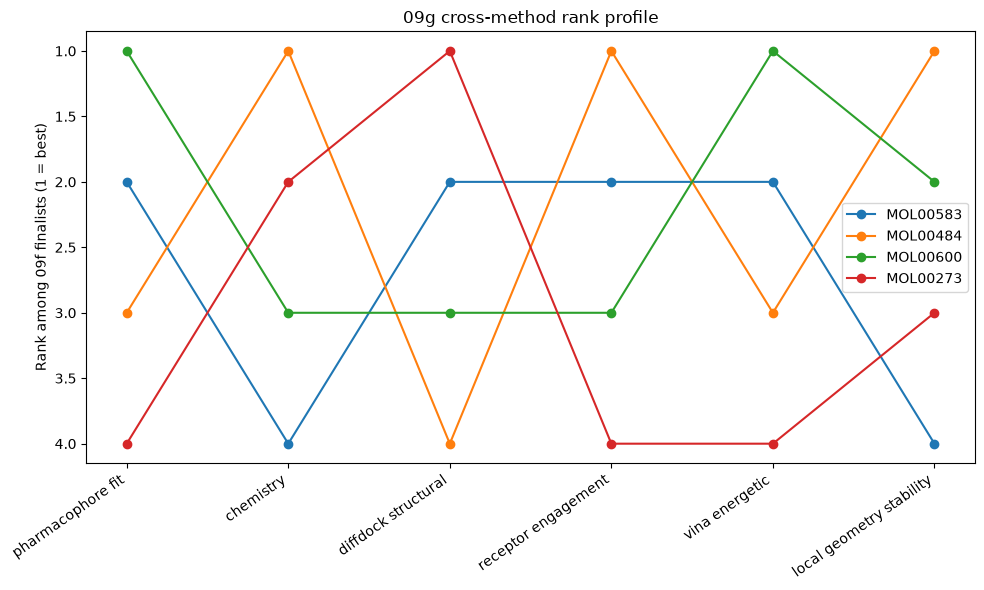

Saved: outputs/pipeline_5_pharmacophore_09g_integrated_lead_selection/plots/09g_cross_method_rank_profile.png


In [16]:
rank_plot_df = (
    integrated[
        [
            "candidate_id",
        ]
        + rank_axis_cols
    ]
    .set_index(
        "candidate_id"
    )
    .T
)

plt.figure(
    figsize=(10, 6)
)

for candidate in rank_plot_df.columns:
    plt.plot(
        np.arange(
            len(
                rank_plot_df.index
            )
        ),
        rank_plot_df[
            candidate
        ].values,
        marker="o",
        label=candidate,
    )

plt.xticks(
    np.arange(
        len(
            rank_plot_df.index
        )
    ),
    [
        x.replace(
            "_rank",
            "",
        ).replace(
            "_",
            " "
        )
        for x in rank_plot_df.index
    ],
    rotation=35,
    ha="right",
)

plt.ylabel(
    "Rank among 09f finalists (1 = best)"
)

plt.title(
    "09g cross-method rank profile"
)

plt.gca().invert_yaxis()

plt.legend()

plt.tight_layout()

rank_plot_path = (
    PLOT_DIR
    / "09g_cross_method_rank_profile.png"
)

plt.savefig(
    rank_plot_path,
    dpi=250,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    rank_plot_path,
)


## 17. Visualization — DiffDock support vs Vina score


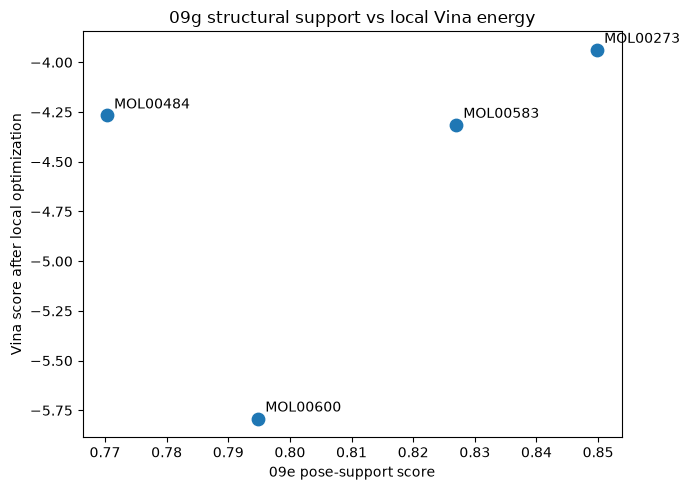

Saved: outputs/pipeline_5_pharmacophore_09g_integrated_lead_selection/plots/09g_diffdock_vs_vina.png


In [17]:
plt.figure(
    figsize=(7, 5)
)

plt.scatter(
    integrated[
        "pose_support_score"
    ],
    integrated[
        "vina_score_after"
    ],
    s=80,
)

for _, row in integrated.iterrows():
    plt.annotate(
        row[
            "candidate_id"
        ],
        (
            row[
                "pose_support_score"
            ],
            row[
                "vina_score_after"
            ],
        ),
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.xlabel(
    "09e pose-support score"
)

plt.ylabel(
    "Vina score after local optimization"
)

plt.title(
    "09g structural support vs local Vina energy"
)

plt.tight_layout()

scatter_path = (
    PLOT_DIR
    / "09g_diffdock_vs_vina.png"
)

plt.savefig(
    scatter_path,
    dpi=250,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    scatter_path,
)


## 18. Visualization — local refinement displacement


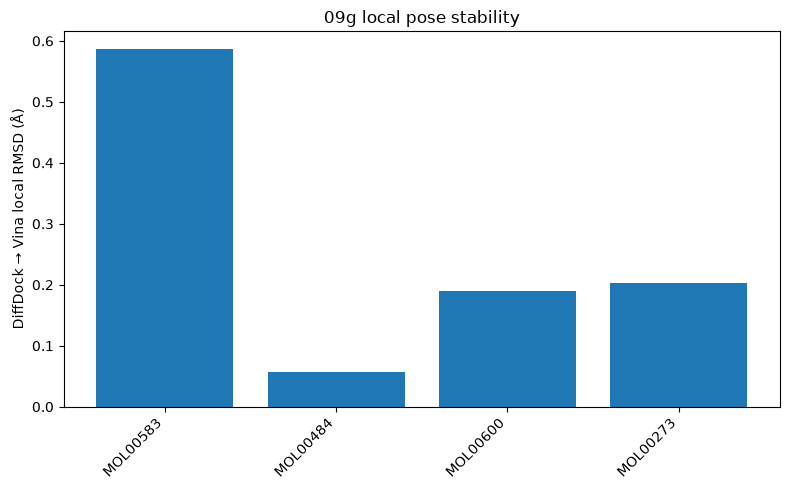

Saved: outputs/pipeline_5_pharmacophore_09g_integrated_lead_selection/plots/09g_local_refinement_RMSD.png


In [18]:
plot_df = integrated.sort_values(
    "09g_priority_rank"
)

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    plot_df[
        "candidate_id"
    ],
    plot_df[
        "diffdock_to_vina_local_RMSD_A"
    ],
)

plt.ylabel(
    "DiffDock → Vina local RMSD (Å)"
)

plt.title(
    "09g local pose stability"
)

plt.xticks(
    rotation=45,
    ha="right",
)

plt.tight_layout()

rmsd_plot_path = (
    PLOT_DIR
    / "09g_local_refinement_RMSD.png"
)

plt.savefig(
    rmsd_plot_path,
    dpi=250,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    rmsd_plot_path,
)


## 19. Copy the refined structures of the final panel

09f Vina-local-minimized structures are preferred when available. The original selected
DiffDock structures remain the reference for the pre-refinement pose.


In [19]:
structure_index_rows = []

if PATHS[
    "09f_structures"
].exists():
    struct09f = pd.read_csv(
        PATHS[
            "09f_structures"
        ]
    )
else:
    struct09f = pd.DataFrame()

pose_files09e = pd.read_csv(
    PATHS[
        "09e_selected_pose_files"
    ]
)

for _, row in integrated.iterrows():
    cid = row[
        "candidate_id"
    ]

    copied_09f = False
    copied_09e = False
    dst_09f = None
    dst_09e = None

    if (
        len(
            struct09f
        )
        and
        "candidate_id" in struct09f.columns
    ):
        match = struct09f[
            struct09f[
                "candidate_id"
            ].astype(str)
            ==
            str(cid)
        ]

        if len(
            match
        ):
            candidate_path = None

            for col in [
                "sdf_path",
                "pdbqt_path",
            ]:
                if (
                    col in match.columns
                    and
                    pd.notna(
                        match.iloc[0][
                            col
                        ]
                    )
                ):
                    p = Path(
                        match.iloc[0][
                            col
                        ]
                    )

                    if p.exists():
                        candidate_path = p
                        break

            if candidate_path is not None:
                dst_09f = (
                    STRUCTURE_DIR
                    / (
                        f"{int(row['09g_priority_rank']):02d}_"
                        f"{cid}_09f_refined"
                        f"{candidate_path.suffix}"
                    )
                )

                shutil.copy2(
                    candidate_path,
                    dst_09f,
                )

                copied_09f = True

    match09e = pose_files09e[
        pose_files09e[
            "candidate_id"
        ].astype(str)
        ==
        str(cid)
    ]

    if len(
        match09e
    ):
        src09e = Path(
            match09e.iloc[0][
                "selected_pose"
            ]
        )

        if src09e.exists():
            dst_09e = (
                STRUCTURE_DIR
                / (
                    f"{int(row['09g_priority_rank']):02d}_"
                    f"{cid}_09e_diffdock_selected.sdf"
                )
            )

            shutil.copy2(
                src09e,
                dst_09e,
            )

            copied_09e = True

    structure_index_rows.append({
        "candidate_id": cid,
        "09g_priority_rank": int(
            row[
                "09g_priority_rank"
            ]
        ),
        "09f_refined_copied": copied_09f,
        "09f_refined_path": str(
            dst_09f
        )
        if dst_09f is not None
        else "",
        "09e_diffdock_copied": copied_09e,
        "09e_diffdock_path": str(
            dst_09e
        )
        if dst_09e is not None
        else "",
    })

structure_index_df = pd.DataFrame(
    structure_index_rows
)

display(
    structure_index_df
)

structure_index_df.to_csv(
    TABLE_DIR
    / "09g_structure_index.csv",
    index=False,
)


,candidate_id,09g_priority_rank,09f_refined_copied,09f_refined_path,09e_diffdock_copied,09e_diffdock_path
0,MOL00583,1,True,outputs/pipeline_5_pharmacophore_09g_integrate...,True,outputs/pipeline_5_pharmacophore_09g_integrate...
1,MOL00484,2,True,outputs/pipeline_5_pharmacophore_09g_integrate...,True,outputs/pipeline_5_pharmacophore_09g_integrate...
2,MOL00600,3,True,outputs/pipeline_5_pharmacophore_09g_integrate...,True,outputs/pipeline_5_pharmacophore_09g_integrate...
3,MOL00273,4,True,outputs/pipeline_5_pharmacophore_09g_integrate...,True,outputs/pipeline_5_pharmacophore_09g_integrate...


## 20. Pipeline-5 final QC


In [20]:
qc_rows = [
    {
        "check": "all_upstream_QC_passed",
        "pass": bool(
            qc_summary_df[
                "all_qc_passed"
            ].all()
        ),
    },
    {
        "check": "09f_finalist_panel_nonempty",
        "pass": (
            len(
                integrated
            )
            > 0
        ),
    },
    {
        "check": "candidate_ids_unique",
        "pass": (
            integrated[
                "candidate_id"
            ].nunique()
            ==
            len(
                integrated
            )
        ),
    },
    {
        "check": "all_finalists_chemistry_pass",
        "pass": bool(
            (
                integrated[
                    "chemistry_class"
                ]
                ==
                "CHEM_PASS"
            ).all()
        ),
    },
    {
        "check": "near_miss_status_preserved",
        "pass": bool(
            (
                integrated[
                    "pharmacophore_status"
                ]
                ==
                "NEAR_MISS_MANDATORY_ONLY"
            ).all()
        ),
    },
    {
        "check": "rescue_track_preserved",
        "pass": bool(
            (
                integrated[
                    "docking_track"
                ]
                ==
                "NEAR_MISS_RESCUE"
            ).all()
        ),
    },
    {
        "check": "no_selected_pose_severe_clash",
        "pass": bool(
            (
                ~integrated[
                    "severe_clash"
                ].astype(bool)
            ).all()
        ),
    },
    {
        "check": "all_vina_scores_finite",
        "pass": bool(
            np.isfinite(
                integrated[
                    [
                        "vina_score_before",
                        "vina_score_after",
                    ]
                ].to_numpy(
                    dtype=float
                )
            ).all()
        ),
    },
    {
        "check": "all_local_RMSD_finite",
        "pass": bool(
            np.isfinite(
                integrated[
                    "diffdock_to_vina_local_RMSD_A"
                ].to_numpy(
                    dtype=float
                )
            ).all()
        ),
    },
    {
        "check": "exactly_one_primary_computational_lead",
        "pass": (
            (
                integrated[
                    "priority_tier"
                ]
                ==
                "TIER_1_PRIMARY_COMPUTATIONAL_LEAD"
            ).sum()
            == 1
        ),
    },
    {
        "check": "integrated_table_exported",
        "pass": (
            TABLE_DIR
            / "09g_integrated_lead_priority.csv"
        ).exists(),
    },
]

qc_df = pd.DataFrame(
    qc_rows
)

ALL_QC_PASSED = bool(
    qc_df[
        "pass"
    ].all()
)

display(
    qc_df
)

print(
    "ALL QC PASSED:",
    ALL_QC_PASSED,
)

qc_df.to_csv(
    TABLE_DIR
    / "09g_QC.csv",
    index=False,
)


,check,pass
0,all_upstream_QC_passed,True
1,09f_finalist_panel_nonempty,True
2,candidate_ids_unique,True
3,all_finalists_chemistry_pass,True
4,near_miss_status_preserved,True
5,rescue_track_preserved,True
6,no_selected_pose_severe_clash,True
7,all_vina_scores_finite,True
8,all_local_RMSD_finite,True
9,exactly_one_primary_computational_lead,True


ALL QC PASSED: True


## 21. Automatic final Pipeline-5 report


In [21]:
report_lines = [
    "# 09g — Integrated Pipeline-5 Lead Selection",
    "",
    "## Pipeline status",
    "- 09b pharmacophore consolidation: COMPLETE",
    "- 09c molecular generation/acquisition + pharmacophore screening: COMPLETE",
    "- 09d chemical filtering / drug-likeness / diversity: COMPLETE",
    "- 09e DiffDock docking + contact analysis: COMPLETE",
    "- 09f Vina local energetic refinement: COMPLETE",
    "",
    "## Funnel",
]

for _, row in funnel_df.iterrows():
    report_lines.append(
        (
            f"- {row['stage']}: "
            f"{row['n']} "
            f"({row['detail']})"
        )
    )

report_lines.extend([
    "",
    "## Integrated finalists",
])

for _, row in integrated.iterrows():
    report_lines.append(
        (
            f"- {int(row['09g_priority_rank'])}. "
            f"{row['candidate_id']} | "
            f"{row['priority_tier']} | "
            f"support={int(row['consensus_support_count_top2'])}/"
            f"{len(rank_axis_cols)} axes | "
            f"pharm RMSD={row['mandatory_rmsd_A']:.3f} Å | "
            f"09e rank={int(row['09e_candidate_rank'])} | "
            f"DiffDock conf={row['diffdock_confidence']:.3f} | "
            f"pose support={row['pose_support_score']:.3f} | "
            f"Vina after={row['vina_score_after']:.3f} | "
            f"local RMSD={row['diffdock_to_vina_local_RMSD_A']:.3f} Å"
        )
    )

if primary_lead is not None:
    cid = primary_lead[
        "candidate_id"
    ]

    primary_rationale = rationale_df[
        rationale_df[
            "candidate_id"
        ]
        ==
        cid
    ].iloc[0]

    report_lines.extend([
        "",
        "## Primary computational lead",
        f"- Candidate: {cid}",
        (
            "- Interpretation: highest cross-method priority under the "
            "transparent rank-based convergence rule used in 09g."
        ),
        (
            "- Main supporting evidence: "
            + primary_rationale[
                "strengths"
            ]
        ),
        (
            "- Main caveats: "
            + primary_rationale[
                "cautions"
            ]
        ),
    ])

report_lines.extend([
    "",
    "## Critical interpretation",
    (
        "- No current 09f/09g finalist is relabeled as a strict pharmacophore hit; "
        "all remain NEAR_MISS_RESCUE / NEAR_MISS_MANDATORY_ONLY."
    ),
    (
        "- DiffDock confidence, pose-support metrics, chemistry scores and Vina "
        "scores retain separate meanings and are not added into a physical "
        "binding-energy quantity."
    ),
    (
        "- Vina local refinement is an empirical energetic comparison, not "
        "MM-GBSA/MM-PBSA and not a rigorous binding free energy."
    ),
    (
        "- Rank disagreement between methods is retained as scientific information."
    ),
    (
        "- Experimental binding and functional assays would be required to validate "
        "the computational priority."
    ),
    "",
    f"ALL QC PASSED: {ALL_QC_PASSED}",
])

report_text = "\n".join(
    report_lines
)

report_path = (
    REPORT_DIR
    / "09g_pipeline5_final_report.md"
)

report_path.write_text(
    report_text,
    encoding="utf-8",
)

print(
    report_text
)

print(
    "\nReport:",
    report_path.resolve(),
)


# 09g — Integrated Pipeline-5 Lead Selection

## Pipeline status
- 09b pharmacophore consolidation: COMPLETE
- 09c molecular generation/acquisition + pharmacophore screening: COMPLETE
- 09d chemical filtering / drug-likeness / diversity: COMPLETE
- 09e DiffDock docking + contact analysis: COMPLETE
- 09f Vina local energetic refinement: COMPLETE

## Funnel
- 09b consolidated pharmacophore: 9 (mandatory=nan, optional=nan)
- 09c molecules ranked: 1000 (production library assessed)
- 09c strict pharmacophore hits: 2 (strict screen_pass candidates)
- 09d docking shortlist: 8 (chemically eligible rescue candidates)
- 09e DiffDock candidates: 8 (one selected pose per candidate)
- 09f Vina-refined finalists: 4 (top 09e candidates refined energetically)

## Integrated finalists
- 1. MOL00583 | TIER_1_PRIMARY_COMPUTATIONAL_LEAD | support=4/6 axes | pharm RMSD=1.341 Å | 09e rank=2 | DiffDock conf=-2.020 | pose support=0.827 | Vina after=-4.314 | local RMSD=0.586 Å
- 2. MOL00484 | TIER_2_ORTHOGONA

# 22. Final conclusion

When this notebook ends with:

```text
ALL QC PASSED: True
```

**Pipeline 5 is complete.**

The primary computational lead is the compound with the strongest transparent
cross-method convergence under the current prototype. The remaining Pareto-nondominated
finalists should be retained as orthogonal follow-up leads because they may be preferred by
different structural, chemical or energetic criteria.

The final interpretation should therefore distinguish:

```text
computational priority
≠
predicted absolute binding free energy
≠
experimental validation
```

This is the intended endpoint before technical-report and presentation integration.
